## Prueba de rendimiento de acceso a disco

Este experimento analiza el rendimiento del acceso a disco considerando:

- Repetición y promedio de resultados
- Lectura vs escritura
- SSD local vs disco de red
- Tamaño del archivo (efecto de caché)
- Caché caliente vs caché fría

---

## 1. Importaciones y Configuración



In [7]:
import os
import time
import random
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# CONFIGURACIÓN BASE
# ==============================
FILE_PATH = "test.bin"
FILE_LOCAL = "test_local.bin"
FILE_REMOTE =  r"\\ALEJANDRA2106\datos_remotos\test.bin" 
FILE_SIZES = [32*1024*1024, 64*1024*1024]  # 32MB, 64MB
BLOCK_SIZES = [4096, 16384, 65536, 131072, 262144]
REPETITIONS = 3
os.makedirs("images_repeticion_experimento", exist_ok=True)


## 2. Funciones

Las funciones implementadas permiten medir, comparar y analizar el rendimiento del almacenamiento bajo distintos patrones de acceso (secuencial vs aleatorio) y tamaños de bloque.


In [8]:
def create_file(p,s):
    with open(p,'wb') as f: 
        f.write(os.urandom(s))
def seq_read(p,b):
    t=time.time()
    with open(p,'rb') as f:
      while f.read(b): 
          pass
    return time.time()-t    
def rnd_read(p, b, s):
    t = time.time()
    with open(p, 'rb') as f:
        for _ in range(s // b):
            f.seek(random.randint(0, s - b))
            f.read(b)
    return time.time() - t
def seq_write(p,b,s):
    d=os.urandom(b); 
    t=time.time()
    with open(p,'wb') as f:
        for _ in range(s//b): 
            f.write(d)
    return time.time()-t
def clear_cache():
    with open("dummy.bin", "wb") as f:
        f.write(os.urandom(20 * 1024 * 1024))
    with open("dummy.bin", "rb") as f:
        f.read()



## 3. Repetir el experimento y promediar resultados

Este experimento ejecuta múltiples corridas para reducir la variabilidad y obtener resultados más confiables mediante el promedio.



1. Promedios de múltiples ejecuciones
Block 4KiB -> Seq: 0.0262s | Rnd: 0.0726s | Seq TP: 1223.07 MiB/s | Rnd TP: 440.67 MiB/s | Speedup: 2.78x
Block 16KiB -> Seq: 0.0126s | Rnd: 0.0205s | Seq TP: 2540.37 MiB/s | Rnd TP: 1563.38 MiB/s | Speedup: 1.62x
Block 64KiB -> Seq: 0.0083s | Rnd: 0.0097s | Seq TP: 3866.31 MiB/s | Rnd TP: 3285.17 MiB/s | Speedup: 1.18x
Block 128KiB -> Seq: 0.0073s | Rnd: 0.0079s | Seq TP: 4403.42 MiB/s | Rnd TP: 4041.97 MiB/s | Speedup: 1.09x
Block 256KiB -> Seq: 0.0080s | Rnd: 0.0088s | Seq TP: 4020.30 MiB/s | Rnd TP: 3633.82 MiB/s | Speedup: 1.11x


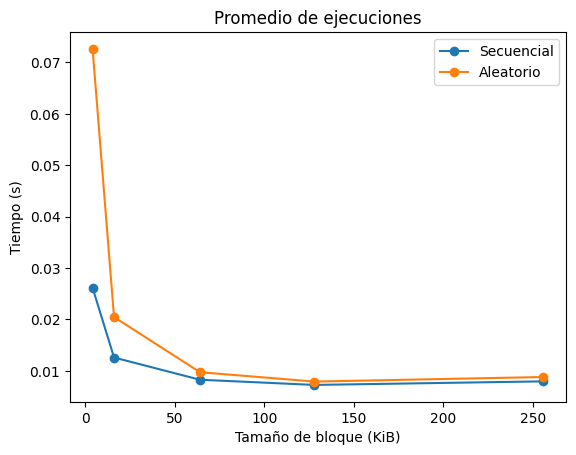

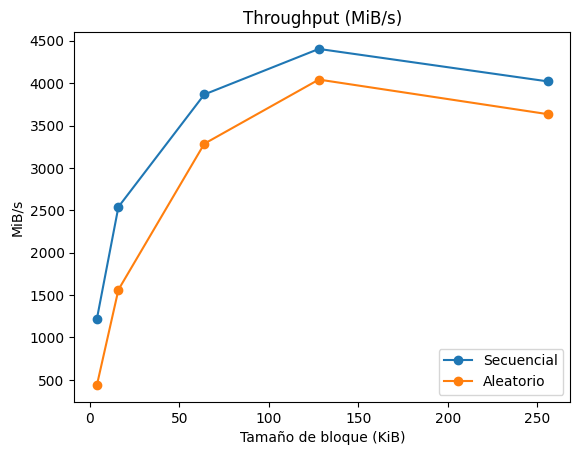

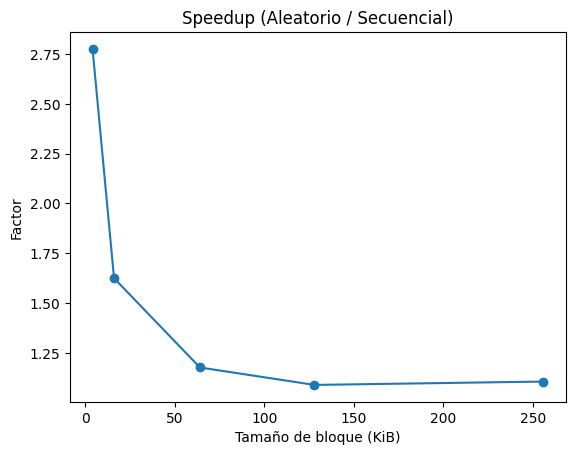

In [3]:
print("\n1. Promedios de múltiples ejecuciones")

create_file(FILE_PATH, FILE_SIZES[0])

blocks = []
seq_avg = []
rnd_avg = []
seq_throughput = []
rnd_throughput = []
speedup = []

file_size_mib = FILE_SIZES[0] / (1024 * 1024)  # tamaño en MB

for b in BLOCK_SIZES:
    s_times = []
    r_times = []

    for _ in range(REPETITIONS):
        clear_cache()
        s_times.append(seq_read(FILE_PATH, b))
        r_times.append(rnd_read(FILE_PATH, b, FILE_SIZES[0]))

    blocks.append(b // 1024)
    seq_avg.append(np.mean(s_times))
    rnd_avg.append(np.mean(r_times))
    seq_tp = file_size_mib / np.mean(s_times)
    rnd_tp = file_size_mib / np.mean(r_times)
    seq_throughput.append(seq_tp)
    rnd_throughput.append(rnd_tp)
    sp = np.mean(r_times) / np.mean(s_times)
    speedup.append(sp)
    print(
        f"Block {b//1024}KiB -> "
        f"Seq: { np.mean(s_times):.4f}s | Rnd: {np.mean(r_times):.4f}s | "
        f"Seq TP: {seq_tp:.2f} MiB/s | Rnd TP: {rnd_tp:.2f} MiB/s | "
        f"Speedup: {sp:.2f}x"
    )

plt.figure()
plt.plot(blocks, seq_avg, marker='o', label='Secuencial')
plt.plot(blocks, rnd_avg, marker='o', label='Aleatorio')
plt.xlabel('Tamaño de bloque (KiB)')
plt.ylabel('Tiempo (s)')
plt.title('Promedio de ejecuciones')
plt.legend(loc='upper right')
plt.savefig("images_repeticion_experimento/promedio_repeticiones.png") 
plt.show()
#Throughput
plt.figure()
plt.plot(blocks, seq_throughput, marker='o', label='Secuencial')
plt.plot(blocks, rnd_throughput, marker='o', label='Aleatorio')
plt.xlabel('Tamaño de bloque (KiB)')
plt.ylabel('MiB/s')
plt.title('Throughput (MiB/s)')
plt.legend(loc='lower right')
plt.savefig("images_repeticion_experimento/throughput.png")
plt.show()
#Speedup
plt.figure()
plt.plot(blocks, speedup, marker='o')
plt.xlabel('Tamaño de bloque (KiB)')
plt.ylabel('Factor')
plt.title('Speedup (Aleatorio / Secuencial)')
plt.savefig("images_repeticion_experimento/speedup.png")
plt.show()


## 4. Comparar lectura y escritura

Se comparan operaciones de lectura y escritura para analizar diferencias de rendimiento.



2. Lectura vs Escritura
Block 4KiB -> Read: 0.0409s | Write: 0.1373s
Block 16KiB -> Read: 0.0323s | Write: 0.0715s
Block 64KiB -> Read: 0.0249s | Write: 0.0392s
Block 128KiB -> Read: 0.0248s | Write: 0.0333s
Block 256KiB -> Read: 0.0284s | Write: 0.0280s


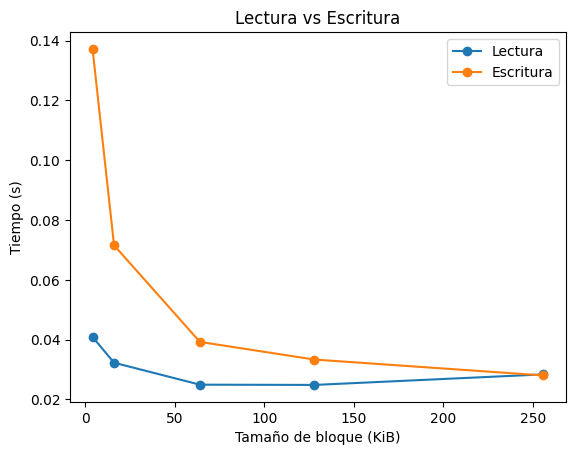

In [4]:
print("\n2. Lectura vs Escritura")

create_file(FILE_PATH, FILE_SIZES[0])

blocks = []
read_times = []
write_times = []

for b in BLOCK_SIZES:
    r = seq_read(FILE_PATH, b)
    w = seq_write(FILE_PATH, b, FILE_SIZES[0])

    blocks.append(b // 1024)
    read_times.append(r)
    write_times.append(w)

    print(f"Block {b//1024}KiB -> Read: {r:.4f}s | Write: {w:.4f}s")

plt.figure()
plt.plot(blocks, read_times, marker='o', label='Lectura')
plt.plot(blocks, write_times, marker='o', label='Escritura')
plt.xlabel('Tamaño de bloque (KiB)')
plt.ylabel('Tiempo (s)')
plt.title('Lectura vs Escritura')
plt.legend(loc='upper right')
plt.savefig("images_repeticion_experimento/lectura_vs_escritura.png") 
plt.show()


## 5. SSD local vs disco de red

Se compara el rendimiento entre almacenamiento local y almacenamiento en red.



3. Local vs Remoto
Block 4KiB -> Local: 0.0407s | Remote: 0.0709s
Block 16KiB -> Local: 0.0130s | Remote: 0.0208s
Block 64KiB -> Local: 0.0086s | Remote: 0.0124s
Block 128KiB -> Local: 0.0081s | Remote: 0.0106s
Block 256KiB -> Local: 0.0085s | Remote: 0.0098s


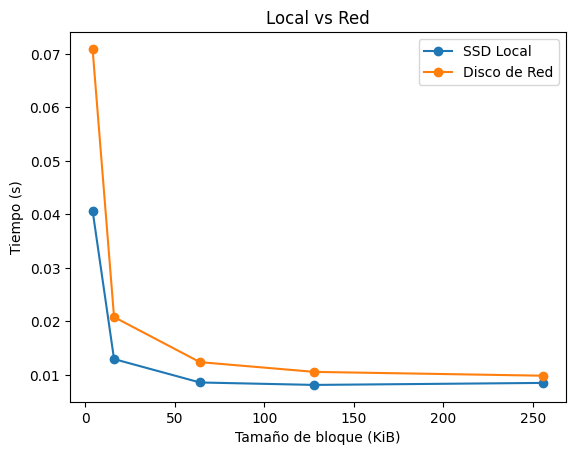

In [9]:
print("\n3. Local vs Remoto")

create_file(FILE_LOCAL, FILE_SIZES[0])
if not os.path.exists(FILE_REMOTE):
    create_file(FILE_REMOTE, FILE_SIZES[0])
blocks = []
local_times = []
remote_times = []


for b in BLOCK_SIZES:
    clear_cache()
    l = seq_read(FILE_LOCAL, b)

    if FILE_REMOTE:
        clear_cache()
        r = seq_read(FILE_REMOTE, b)
    else:
        r = 0  # si no hay disco de red
        
    blocks.append(b // 1024)
    local_times.append(l)
    remote_times.append(r)
    print(f"Block {b//1024}KiB -> Local: {l:.4f}s | Remote: {r:.4f}s")

plt.figure()
plt.plot(blocks, local_times, marker='o', label='SSD Local')
if FILE_REMOTE:
    plt.plot(blocks, remote_times, marker='o', label='Disco de Red')


plt.title("Local vs Red")
plt.xlabel("Tamaño de bloque (KiB)")
plt.ylabel("Tiempo (s)")
plt.legend()  
plt.savefig("images_repeticion_experimento/local_vs_red.png")
plt.show()

## 6. Cambiar tamaño del archivo (efecto caché)

Se evalúa cómo el tamaño del archivo afecta el uso de caché del sistema.




4. Tamaño del archivo
32 MB -> 0.0418s
64 MB -> 0.0536s


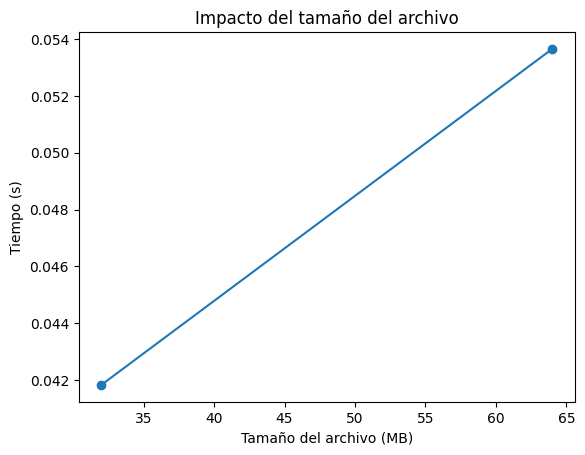

In [6]:
print("\n4. Tamaño del archivo")

sizes = []
times = []

for s in FILE_SIZES:
    create_file(FILE_PATH, s)
    t = seq_read(FILE_PATH, 4096)

    sizes.append(s // 1024 // 1024)
    times.append(t)

    print(f"{sizes[-1]} MB -> {t:.4f}s")

plt.figure()
plt.plot(sizes, times, marker='o')
plt.xlabel('Tamaño del archivo (MB)')
plt.ylabel('Tiempo (s)')
plt.title('Impacto del tamaño del archivo')
plt.savefig("images_repeticion_experimento/tamaño_archivo_efecto_caché.png") 
plt.show()

## 7. Caché caliente vs caché fría

Se ejecuta el mismo experimento dos veces para observar el efecto de la caché del sistema operativo.




5. Caché fría vs caliente
Cold: 0.0403s | Warm: 0.0244s


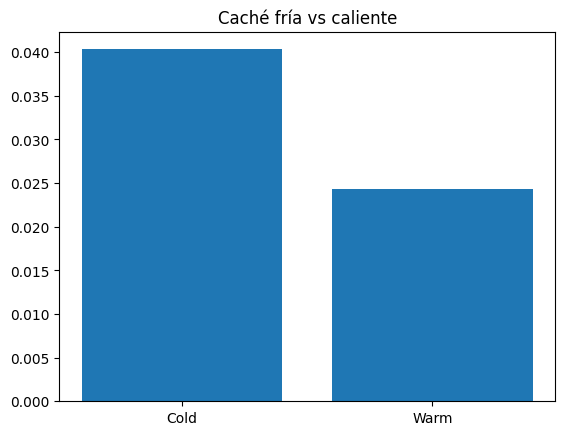

In [7]:
print("\n5. Caché fría vs caliente")

create_file(FILE_PATH, FILE_SIZES[0])

cold = seq_read(FILE_PATH, 4096)
warm = seq_read(FILE_PATH, 4096)

print(f"Cold: {cold:.4f}s | Warm: {warm:.4f}s")

plt.figure()
plt.bar(["Cold", "Warm"], [cold, warm])
plt.title('Caché fría vs caliente')
plt.savefig("images_repeticion_experimento/cache_fria_vs_caliente.png") 
plt.show()